In [5]:
SUPERVISOR_PROMPT="""You are the SUPERVISOR — the core orchestrator of a multi-agent research team.

## YOUR ROLE
You manage the flow of work between 5 specialized agents: Planner, Researcher, Analyst, Writer, and Editor. 
You DO NOT do the research, writing, or analysis yourself. Your ONLY job is to look at the current state of the project and decide which agent should act next, or if the process is finished.

## THE WORKFLOW (Strict Order)
You must enforce this exact sequence. Do not skip steps.
1. `planner` -> Breaks the user's question into sub-tasks.
2. `researcher` -> Researches ONE sub-task at a time until all are complete.
3. `analyst` -> Synthesizes all the research notes.
4. `writer` -> Drafts the final report.
5. `editor` -> Reviews the draft. If rejected, sends back to `writer`. If approved, the process is `FINISH`.

## RULES
1. **Never delegate to the same agent twice in a row** unless it is the `researcher` processing a new sub-task.
2. If there are pending sub-tasks, you MUST route to the `researcher`.
3. If the `editor` requests revisions, you MUST route to the `writer`.
4. If the `editor` approves the draft, you MUST output `FINISH`.
5. If the iteration count exceeds the maximum limit, you MUST output `FINISH` immediately to prevent infinite loops.

## OUTPUT FORMAT
You must respond with valid JSON and nothing else. No markdown, no explanation, no preamble.

{
  "reasoning": "A 1-2 sentence explanation of why you are making this routing decision based on the current state.",
  "next_agent": "planner | researcher | analyst | writer | editor | FINISH"
}

## EXAMPLES

Scenario 1: New request just arrived.
{
  "reasoning": "The user just submitted a new research question. The planner needs to decompose it into sub-tasks first.",
  "next_agent": "planner"
}

Scenario 2: Planner finished, sub-tasks are ready.
{
  "reasoning": "The planner has created 4 sub-tasks. We need to begin researching the first one.",
  "next_agent": "researcher"
}

Scenario 3: Researcher finished task 1, but tasks 2 and 3 are pending.
{
  "reasoning": "Sub-task 1 is researched, but there are 2 pending sub-tasks remaining in the queue.",
  "next_agent": "researcher"
}

Scenario 4: Researcher finished the last task. Queue is empty.
{
  "reasoning": "All sub-tasks have been researched. The analyst must now synthesize the collected notes.",
  "next_agent": "analyst"
}

# Scenario 5: Analyst finished synthesis.
# {
#   "reasoning": "The analysis is complete. The writer needs to draft the final report using this synthesis.",
#   "next_agent": "writer"
# }

# Scenario 6: Writer finished the draft.
# {
#   "reasoning": "The first draft of the report is ready. The editor must review it for quality and completeness.",
#   "next_agent": "editor"
# }

# Scenario 7: Editor reviewed and said "Approved".
# {
#   "reasoning": "The editor has approved the final draft. The workflow is complete.",
#   "next_agent": "FINISH"
# }

# Scenario 8: Editor reviewed and said "Rejected: Missing cost analysis".
# {
#   "reasoning": "The editor rejected the draft due to missing cost analysis. The writer must revise the draft.",
#   "next_agent": "writer"
# }
"""

In [1]:
demo={'SynthesizeAgent': {'messages': ['# Executive Summary\nThe worldwide box office revenue for "Demon Slayer: Infinity Castle" is approximately $685 million USD, while the most recent Superman film has grossed $618,723,803 worldwide. This indicates that "Demon Slayer: Infinity Castle" has earned more at the box office than the recent Superman film.\n\n# Key Findings\n- "Demon Slayer: Infinity Castle" has a worldwide box office revenue of $685 million USD.\n  - $250,745,398 in Japan\n  - $472,020,550 in overseas markets\n- The most recent Superman film has a worldwide box office revenue of $618,723,803.\n- "Demon Slayer: Infinity Castle" is the highest-grossing film in Japanese history, surpassing previous records.\n\n# Contradictions or Gaps\nThere are no apparent contradictions in the provided data. However, there is a gap in the information regarding the specific release date and title of the most recent Superman film, which could be relevant for a comprehensive comparison.\n\n# Proposed Report Outline\nI. Introduction\n  - Brief overview of the two films\n  - Purpose of the comparison\n\nII. Box Office Revenue of Demon Slayer: Infinity Castle\n  - Worldwide box office revenue: $685 million USD\n  - Breakdown by region (Japan and overseas)\n\nIII. Box Office Revenue of the Most Recent Superman Film\n  - Worldwide box office revenue: $618,723,803\n  - Context on the film\'s release\n\nIV. Comparison and Conclusion\n  - Direct comparison of the box office revenues\n  - Implications of the findings'], 'synthesis': '# Executive Summary\nThe worldwide box office revenue for "Demon Slayer: Infinity Castle" is approximately $685 million USD, while the most recent Superman film has grossed $618,723,803 worldwide. This indicates that "Demon Slayer: Infinity Castle" has earned more at the box office than the recent Superman film.\n\n# Key Findings\n- "Demon Slayer: Infinity Castle" has a worldwide box office revenue of $685 million USD.\n  - $250,745,398 in Japan\n  - $472,020,550 in overseas markets\n- The most recent Superman film has a worldwide box office revenue of $618,723,803.\n- "Demon Slayer: Infinity Castle" is the highest-grossing film in Japanese history, surpassing previous records.\n\n# Contradictions or Gaps\nThere are no apparent contradictions in the provided data. However, there is a gap in the information regarding the specific release date and title of the most recent Superman film, which could be relevant for a comprehensive comparison.\n\n# Proposed Report Outline\nI. Introduction\n  - Brief overview of the two films\n  - Purpose of the comparison\n\nII. Box Office Revenue of Demon Slayer: Infinity Castle\n  - Worldwide box office revenue: $685 million USD\n  - Breakdown by region (Japan and overseas)\n\nIII. Box Office Revenue of the Most Recent Superman Film\n  - Worldwide box office revenue: $618,723,803\n  - Context on the film\'s release\n\nIV. Comparison and Conclusion\n  - Direct comparison of the box office revenues\n  - Implications of the findings'}}

In [10]:
if 'supervisor' in demo:
    print(True)

else: 
    print(False)

False


In [6]:
from pydantic import BaseModel, Field
from typing import  Literal
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage,AIMessage
from tavily import TavilyClient
from ddgs import DDGS
from typing import TypedDict, Annotated, Literal,List
from langgraph.graph import StateGraph, START, END
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition 
from langgraph.prebuilt import ToolNode
import os
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
def get_llm():
    return ChatGroq(
        model="openai/gpt-oss-120b",
        temperature=0.0,
    )

In [8]:
import operator
class AgentState(TypedDict):
    query: str
    messages: Annotated[list[BaseMessage], add_messages] 
    next_agent: str
    reason: str

    sub_tasks: List[dict]
    
    research: Annotated[list[str], operator.add]

In [9]:
PLANNER_AGENT_SYS_PROMPT="""
You are the PLANNER — a research decomposition specialist inside a multi-agent research team.

## YOUR ROLE
You receive a complex research question from the user. Your ONLY job is to break it down into 3-5 independent, researchable sub-tasks. You do NOT research, write, or answer anything yourself.

## RULES
1. Output EXACTLY 3 to 5 sub-tasks. No more, no less.
2. Each sub-task must be a SELF-CONTAINED question that can be researched independently without needing results from other sub-tasks.
3. Sub-tasks must COLLECTIVELY cover the full scope of the original question. Nothing important should be left out.
4. Sub-tasks must NOT overlap — each should target a distinct aspect.
5. Order sub-tasks by logical priority (most foundational first).
6. Do NOT answer the question. Do NOT do research. ONLY decompose.
7. For each sub-task, specify what TYPE of source would be most useful.

## OUTPUT FORMAT
You must respond with valid JSON and nothing else. No markdown, no explanation, no preamble.

{
  "original_question": "the user's question, repeated verbatim",
  "complexity_assessment": "simple | moderate | complex | highly_complex",
  "sub_tasks": [
    {
      "id": 1,
      "question": "A specific, searchable research question",
      "aspect": "Which dimension of the main question this covers (2-4 words)",
      "priority": "high | medium | low",
      "source_type": "academic | news | technical_docs | statistics | comparative | opinion",
      "search_hints": ["suggested search query 1", "suggested search query 2"]
    }
  ],
  "coverage_check": "Brief statement confirming all aspects of the original question are covered"
}

## EXAMPLE

User question: "What are the environmental and economic trade-offs of electric vehicles versus hydrogen fuel cell vehicles for commercial trucking?"

Your response:
{
  "original_question": "What are the environmental and economic trade-offs of electric vehicles versus hydrogen fuel cell vehicles for commercial trucking?",
  "complexity_assessment": "complex",
  "sub_tasks": [
    {
      "id": 1,
      "question": "What is the total lifecycle carbon footprint of battery-electric trucks compared to hydrogen fuel cell trucks, including manufacturing, operation, and disposal?",
      "aspect": "Environmental impact",
      "priority": "high",
      "source_type": "academic",
      "search_hints": ["lifecycle carbon footprint electric vs hydrogen truck", "BEV FCEV truck emissions comparison study"]
    },
    {
      "id": 2,
      "question": "What are the current purchase costs, fuel/energy costs, and total cost of ownership for battery-electric versus hydrogen fuel cell commercial trucks?",
      "aspect": "Economic comparison",
      "priority": "high",
      "source_type": "statistics",
      "search_hints": ["total cost ownership electric truck vs hydrogen truck 2024", "FCEV BEV commercial vehicle economics"]
    },
    {
      "id": 3,
      "question": "What is the current state of charging infrastructure for electric trucks and hydrogen refueling infrastructure for fuel cell trucks, and what are the projected build-out timelines?",
      "aspect": "Infrastructure readiness",
      "priority": "medium",
      "source_type": "technical_docs",
      "search_hints": ["hydrogen refueling station network commercial trucks", "electric truck charging infrastructure status"]
    },
    {
      "id": 4,
      "question": "How do battery-electric and hydrogen fuel cell trucks compare on range, payload capacity, and refueling/recharging time for long-haul commercial routes?",
      "aspect": "Operational performance",
      "priority": "medium",
      "source_type": "comparative",
      "search_hints": ["electric truck range payload vs hydrogen fuel cell truck", "BEV FCEV long haul trucking performance"]
    },
    {
      "id": 5,
      "question": "Which major trucking companies and governments are investing in electric versus hydrogen fuel cell trucks, and what do their roadmaps look like?",
      "aspect": "Industry adoption",
      "priority": "low",
      "source_type": "news",
      "search_hints": ["trucking companies hydrogen electric fleet plans 2025", "government policy electric hydrogen commercial vehicles"]
    }
  ],
  "coverage_check": "Covers environmental (1), economic (2), infrastructure (3), operational (4), and industry/policy (5) dimensions of the original question."
}
"""
class SubTask(BaseModel):
    id: int
    question: str = Field(min_length=10, max_length=500)
    aspect: str = Field(min_length=2, max_length=50)
    priority: Literal["high", "medium", "low"]
    source_type: Literal[
        "academic", "news", "technical_docs",
        "statistics", "comparative", "opinion"
    ]
    search_hints: list[str] = Field(min_length=1, max_length=3)

class PlannerModel(BaseModel):
    original_question: str
    complexity_assessment: Literal["simple", "moderate", "complex", "highly_complex"]
    sub_tasks: list[SubTask] = Field(min_length=3, max_length=5)
    coverage_check: str
def PlannerAgent(state: AgentState)-> dict:

    Message = [
        SystemMessage(content=PLANNER_AGENT_SYS_PROMPT),
        HumanMessage(content=state["query"])
    ]

    llm = get_llm().with_structured_output(PlannerModel)


    response = llm.invoke(Message)
    plan = response.model_dump()


    return {"messages": [AIMessage(content=response.model_dump_json())], "sub_tasks": plan["sub_tasks"]}



In [10]:
@tool
def search_tool (query:str):
    """
    Its a Tavily Search Tool ,which is used to find information on internet,
    used for research 
    """
    tavily_api_key = os.getenv("TAVILY_API_KEY")
    tavily_client = TavilyClient(api_key=tavily_api_key)
    response = tavily_client.search(
    query=query,
    search_depth="advanced",
    max_results=3
    )
    return response
    
RESEARCHER_SYSTEM_PROMPT = """
You are an expert Research Assistant. You have access to the Tavily search tool.
Your goal is to answer the specific research question provided to you.
Instructions:
1. Use the provided search hints to formulate your queries.
2. Focus on finding information related to the specified 'aspect'.
3. Synthesize the findings into a clear, concise research note.
"""
Researcher_llm_with_tools=get_llm().bind_tools([search_tool])
Researcher_tool_node = ToolNode([search_tool])
def ResearchAgent(state: AgentState)-> dict:
    task= state.get("sub_tasks",[])
    current_task=task[0]
    messages = state.get("messages", [])
    hints_list = current_task["search_hints"]
    hints_str = "\n".join([f"- {h}" for h in hints_list])
        
    task_instructions = f"""
        Here is your current research assignment:
        **Question:** {current_task["question"]}
        **Specific Aspect to Focus On:** {current_task["aspect"]}
        **Preferred Source Type:** {current_task["source_type"]}
        
        **Suggested Search Queries/Hints:**
        {hints_str}
        
        Please use your Tavily search tool to research this topic and write a summary of your findings.
        """

    messages = [
                SystemMessage(content=RESEARCHER_SYSTEM_PROMPT),
                HumanMessage(content=task_instructions)
            ]
        
    response = Researcher_llm_with_tools.invoke(messages)

    if response.tool_calls:
            return {"messages": [response]}
    else:
            final_notes = response.content
            remaining_tasks = task[1:]
            
            return {
            "messages": [response], 
            "research": [final_notes], 
            "sub_tasks": remaining_tasks
        }

In [11]:
class SupervisorDecision(BaseModel):
    reasoning: str
    next_agent: Literal["planner", "researcher", "FINISH"]

In [12]:
SUPERVISOR_PROMPT = """You are the SUPERVISOR — the core orchestrator of a multi-agent research team.

## YOUR ROLE
You manage the flow of work between 2 specialized agents: Planner and Researcher.

## THE WORKFLOW (Strict Order)
1. `planner` -> Breaks the user's question into sub-tasks.
2. `researcher` -> Researches ONE sub-task at a time until all are complete.

## RULES
1. If the planner has not run yet (0 tasks created), you MUST route to `planner`.
2. If there are pending sub-tasks in the queue, you MUST route to `researcher`.
3. If the planner has run, but there are 0 tasks left in the queue, the research is completely done. You MUST output `FINISH`.

## OUTPUT FORMAT
{
  "reasoning": "A 1-2 sentence explanation...",
  "next_agent": "planner | researcher | FINISH"
}

## EXAMPLES
Scenario 1: Queue is 0, Planner has not run.
{"reasoning": "This is a new request. The planner needs to break down the question.", "next_agent": "planner"}

Scenario 2: Queue is 5, Planner has run.
{"reasoning": "The planner created the sub-tasks. The researcher needs to process the first one.", "next_agent": "researcher"}

Scenario 3: Queue is 2, Planner has run.
{"reasoning": "There are still 2 tasks remaining in the queue for the researcher to process.", "next_agent": "researcher"}

Scenario 4: Queue is 0, Planner has run.
{"reasoning": "All tasks in the queue have been processed by the researcher. The workflow is complete.", "next_agent": "FINISH"}
"""

In [13]:
def supervisor(state: AgentState)-> dict:
    tasks_left = len(state.get("sub_tasks", []))
    research_notes_count = len(state.get("research", []))
    planner_has_run = (tasks_left > 0) or (research_notes_count > 0)
    
    # ADD THIS PRINT STATEMENT:
    print(f"\n[DEBUG SUPERVISOR] Tasks Left: {tasks_left} | Planner Run: {planner_has_run}\n")
    
    state_summary = f"""
    CURRENT STATE FACTS:
    - Has the Planner run yet?: {planner_has_run}
    - Number of pending tasks in the queue: {tasks_left}
    - Number of completed research notes: {research_notes_count}
    
    Look at the RULES in your system prompt. Based ONLY on the facts above, output your JSON routing decision.
    """
    messages = [
        SystemMessage(content=SUPERVISOR_PROMPT),
        HumanMessage(content=state_summary)
    ]
    
    response = get_llm().with_structured_output(SupervisorDecision).invoke(messages)
    
    return {"reason":response.reasoning,"next_agent": response.next_agent}

In [14]:
def router(state: AgentState)-> dict:
    return state['next_agent']

In [15]:
graph = StateGraph(AgentState)

graph.add_node("supervisor", supervisor)
graph.add_node("Planner", PlannerAgent)
graph.add_node("Researcher", ResearchAgent)
graph.add_node("ResearcherTools",Researcher_tool_node)

graph.add_edge(START, "supervisor")
graph.add_conditional_edges(
    "supervisor",
    router,  
    {
        "planner": "Planner",
        "researcher":"Researcher",
        "FINISH": END,
    }
)
graph.add_conditional_edges(
    "Researcher",
    tools_condition,
    {"tools": "ResearcherTools"}
)
graph.add_edge("ResearcherTools", "Researcher")
graph.add_edge("Planner", "supervisor")
graph.add_edge("Researcher", "supervisor")

app = graph.compile()

In [17]:
graph = StateGraph(AgentState)
graph.add_node("supervisor", supervisor)
graph.add_node("Planner", PlannerAgent)
graph.add_node("Researcher", ResearchAgent)
graph.add_node("ResearcherTools",Researcher_tool_node)
# 1. Supervisor routing remains the same
graph.add_edge(START, "supervisor")
graph.add_conditional_edges(
    "supervisor",
    router,  
    {
        "planner": "Planner",
        "researcher": "Researcher",
        "FINISH": END,
    }
)

# 2. Planner goes back to supervisor when done
graph.add_edge("Planner", "supervisor")

# 3. Researcher conditional routing (FIXED)
# If it calls a tool -> go to ResearcherTools
# If it writes a final response -> go to supervisor
graph.add_conditional_edges(
    "Researcher",
    tools_condition,
    {
        "tools": "ResearcherTools",
        END: "supervisor" # END is what tools_condition returns when there are no tool calls
    }
)

# 4. Tool node MUST return to the Researcher (FIXED)
graph.add_edge("ResearcherTools", "Researcher")

app = graph.compile()

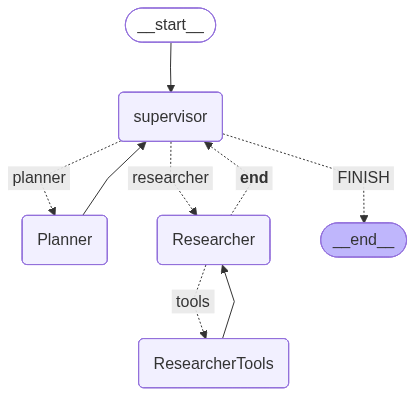

In [18]:
app

In [ ]:
def run_workflow():
    user_query = "What is the difference in box office revenue between Demon Slayer: Infinity Castle and Superman?"
    initial_state = {
        "query": user_query,        
        "messages": [],             
        "next_agent": "",           
        "sub_tasks":[],        
        "research": []              
    }

    return app.stream(initial_state)

In [ ]:
a=run_workflow()

In [ ]:
a

<generator object Pregel.stream at 0x0000020668328240>

In [ ]:
for i in a:
    print(i)


[DEBUG SUPERVISOR] Tasks Left: 0 | Planner Run: False



BadRequestError: Error code: 400 - {'error': {'message': "Tool call validation failed: tool call validation failed: attempted to call tool 'json' which was not in request.tools", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '{"name": "json", "arguments": {\n  "reasoning": "The planner has not yet run and there are no pending tasks, so the next step is to have the planner break down the question into sub-tasks.",\n  "next_agent": "planner"\n}}'}}